# FOMC Speaker Hawk/Dove — USD Front-End SOFR Futures

USD only. The pooled six-currency study answers "does this work anywhere"; this one asks the
narrower and more useful question — **does it work on the Fed, where the data is deepest and the
committee is large enough for "relative to peers" to mean something.**

The FOMC is the only committee here with 26 scored speakers. The BoJ has 12, the SNB has 4 and
Norges has 2 — with two people there is no committee to be relative to. So the labelling idea
that the global study could only gesture at can actually be tested here.

### What is traded

`rateslib.STIRFuture` outrights on **SR3 (3M SOFR, CME)** through
`Query.STIRFutures.STIRFutureQuery`, priced from Barchart minute bars, run on the same
`QueryDrivenBacktest` / `TimeGrid` / `Trigger` / `AddQueryAction` / `UnwindPositionsAction`
pattern as the original notebook. Hawk → rates higher → **pay fixed = SELL the future**.

### The labelling, which is the point of this notebook

A hawk/dove score is only meaningful **relative to the speaker's own committee at that moment**.
In 2022 every FOMC member sounded hawkish in absolute terms; only some were hawkish *relative to
their peers*, and only that difference can move a price that already embeds the consensus.

| scheme | what it asks | FOMC hawk / dove split |
|---|---|---|
| `absolute` | is the score above ±10/±20 | **55% / 8%** — a standing short-rates bet |
| `percentile` | is this speech hawkish *for this speaker* | 38% / 38% |
| **`peer`** | **is this speaker hawkish *for this committee*** | **37% / 41%** |

### Four things measured rather than assumed

| | finding |
|---|---|
| **Direction** | A negative `bpv` does **not** short on this path — it flips both the risk-weighted price and the PV01 and the two cancel, silently giving a LONG. The only correct short is `bpv=+X` with `risk_weights=[-1.0]`. |
| **Intraday** | Without `market_request={"timestamp": "now"}` every query prices off the *daily* bar and all same-day P&L is exactly zero. |
| **Lookahead** | The MDP serves a **later** bar when the request precedes the session's first bar — up to 335 minutes ahead. Every event is gated on a real causal bar at both ends. |
| **Score vintage** | 60.5% of JPM score rows are published *after* the speech, and JPM re-scores history. Every lookup and every reference distribution is gated on publication date, which deletes the pre-2023 sample entirely. |

In [1]:
%load_ext autoreload
%autoreload 2

import sys, pickle, datetime
from pathlib import Path

REPO = r"C:\Users\chris\clee\ARBS-gcb"
HERE = Path(REPO) / "notebooks" / "backtests" / "intraday_fed_hawk_dove"
sys.path.insert(0, REPO); sys.path.insert(0, str(HERE))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns

plt.style.use("ggplot")
pylab.rcParams.update({"figure.figsize": (14, 6), "axes.titlesize": "large",
                       "axes.labelsize": "large"})

import global_hawk_dove_common as G
import global_hawk_dove_grid as GRID
import fomc_extras as FX
from global_hawk_dove_run import (
    SCORES_CSV, BT_START, BT_END, SCORE_METRIC, ENTRY_OFFSET, EXIT_OFFSET,
    BASE_BPV, CONTRACT_RANK, BLACKOUT_BD, MAX_STALENESS_MIN, CACHE,
)
from MDP.STIRFutures.STIRFutureMDP import STIRFutureMDP

BANK = "FED"
cfg = G.CB_CONFIGS[BANK]
mdp = STIRFutureMDP(source="BARCHART_STIRF-RL", cache_full_intraday_fetch=True)

print(f"leg          : {BANK}  root={cfg.root}  ccy={cfg.ccy}")
print(f"session      : {cfg.session_start}-{cfg.session_end} {cfg.market_tz}")
print(f"window       : {BT_START} -> {BT_END}")
print(f"entry / exit : T{int(ENTRY_OFFSET.total_seconds()//60):+d}m / T{int(EXIT_OFFSET.total_seconds()//60):+d}m")
print(f"contract     : {CONTRACT_RANK}rd quarterly SR3, base bpv {BASE_BPV:,.0f}")

C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\global_hawk_dove_common.py:47: LicenceNotice: 
Rateslib is source-available (not open-source) software distributed under a dual-licence model.
No commercial licence is registered for this installation. Use is therefore permitted for non-commercial purposes only (at-home or university based academic use).
Any use in commercial, professional, or for-profit environments, including evaluation or trial use, requires a valid commercial licence or an approved evaluation licence.
Certain features may require a registered commercial or evaluation licence in current or future versions.
For licensing information or to register a licence, please visit: https://rateslib.com/licence
  from rateslib.scheduling import next_imm


leg          : FED  root=SR3  ccy=USD
session      : 07:00:00-16:45:00 America/New_York
window       : 2021-01-01 -> 2026-08-07
entry / exit : T-45m / T+180m
contract     : 3rd quarterly SR3, base bpv 100,000


## 1. The signal

729 scored FOMC speeches, 26 speakers, 2008-11-06 -> 2026-08-06
publication lag (days after the speech): median 1, p90 246


,speeches,mean_score,first,last,role
speaker,,,,,
Bowman,86,5.7,2022-02-21,2026-05-29,Governor
Waller,62,3.5,2022-05-06,2026-07-13,Governor
Powell,59,15.3,2022-07-27,2026-04-29,Governor
Williams,57,7.0,2022-03-25,2026-07-15,President (NY)
Logan,44,9.9,2022-03-02,2026-07-31,President
Collins,42,8.0,2022-09-26,2026-05-13,President
Barkin,40,15.2,2022-03-18,2026-05-21,President
Barr,38,-14.2,2022-12-01,2026-03-26,Governor
Cook,37,4.4,2022-10-06,2026-08-05,Governor


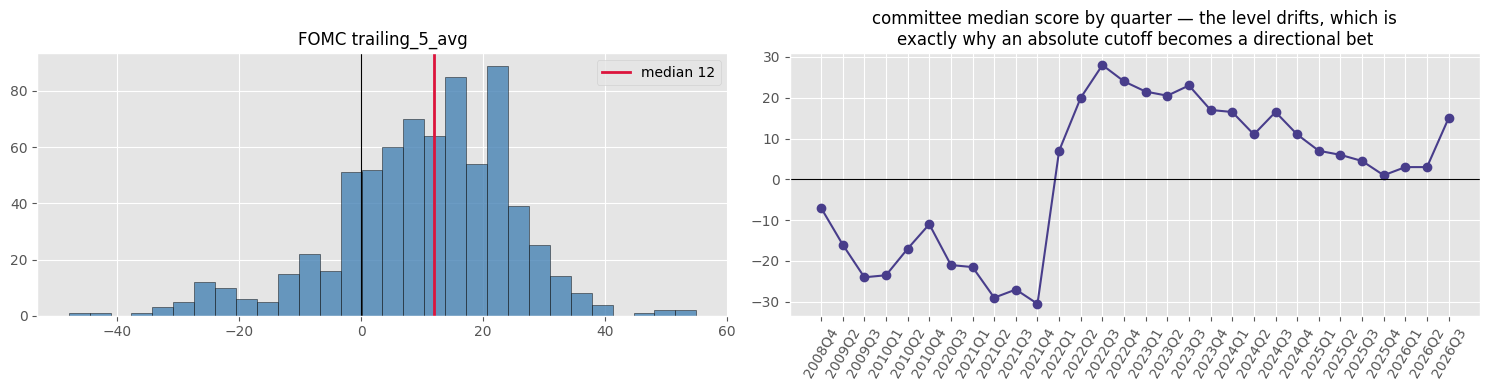

In [2]:
scores = G.load_global_scores(SCORES_CSV, SCORE_METRIC)
fed = scores[scores.central_bank == BANK].copy()

print(f"{len(fed)} scored FOMC speeches, {fed.speaker.nunique()} speakers, "
      f"{fed.date.min()} -> {fed.date.max()}")
print(f"publication lag (days after the speech): median "
      f"{(pd.to_datetime(fed.pub_date) - pd.to_datetime(fed.date)).dt.days.median():.0f}, "
      f"p90 {(pd.to_datetime(fed.pub_date) - pd.to_datetime(fed.date)).dt.days.quantile(.9):.0f}")

top = (fed.groupby("speaker")
       .agg(speeches=("hawk_dove_score", "count"),
            mean_score=("hawk_dove_score", "mean"),
            first=("date", "min"), last=("date", "max"))
       .sort_values("speeches", ascending=False).round(1))
top["role"] = [FX.role_of(s) for s in top.index]
display(top)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].hist(fed[SCORE_METRIC].dropna(), bins=30, color="steelblue",
             alpha=.8, edgecolor="k", lw=.4)
axes[0].axvline(fed[SCORE_METRIC].median(), color="crimson", lw=2,
                label=f"median {fed[SCORE_METRIC].median():.0f}")
axes[0].axvline(0, color="k", lw=.8)
axes[0].set_title(f"FOMC {SCORE_METRIC}"); axes[0].legend()

m = (fed.assign(ym=pd.to_datetime(fed.date).dt.to_period("Q").astype(str))
     .groupby("ym")[SCORE_METRIC].median())
axes[1].plot(m.index, m.values, marker="o", color="darkslateblue")
axes[1].axhline(0, color="k", lw=.8)
axes[1].set_title("committee median score by quarter — the level drifts, which is\n"
                  "exactly why an absolute cutoff becomes a directional bet")
axes[1].tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.show()

### 1.1 Absolute cutoffs turn the FOMC into a standing short

The committee median drifts with the cycle. A fixed ±10/±20 threshold therefore does not measure
hawkishness — it measures *where we are in the cycle*, and puts most of the book on one side of
the market for years at a time.

`peer` fixes this by scoring each speech against the cross-section of the **other** FOMC members'
most recent scores, using only observations that were both prior and already published.

,hawk,neutral,dove,|hawk-dove|
scheme,,,,
absolute,55.1%,36.5%,8.4%,46.8%
percentile,27.0%,37.3%,35.7%,8.6%
peer,26.6%,40.1%,33.3%,6.7%


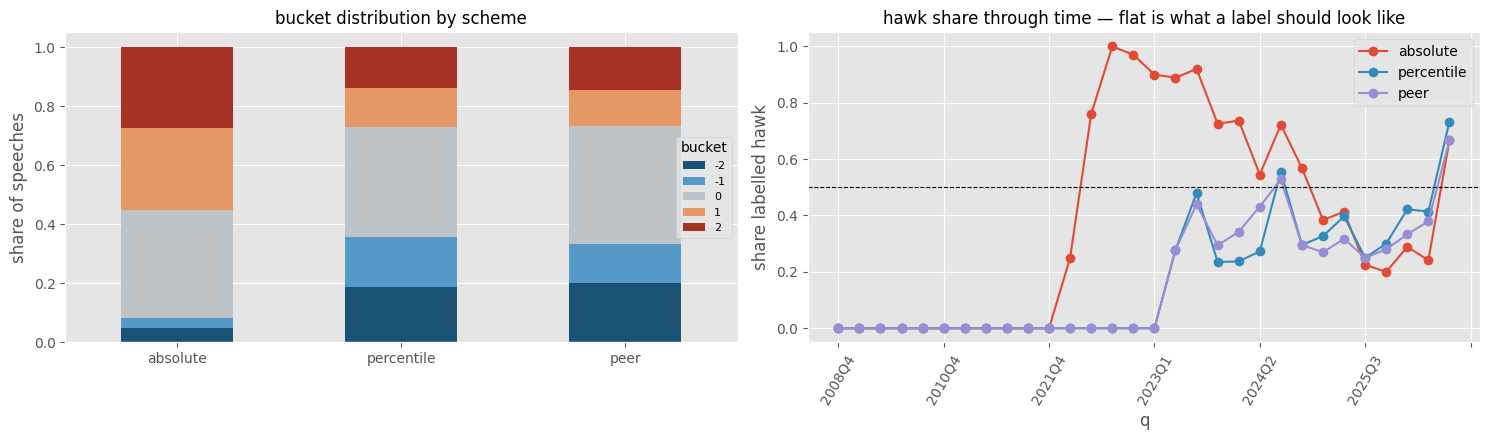

In [3]:
pct = G.make_percentile_bucketer(scores, BANK, SCORE_METRIC)
peer = G.make_peer_relative_bucketer(scores, BANK, SCORE_METRIC, fallback=pct)
SCHEMES = [("absolute", lambda s, x, d: G.absolute_bucket(x)),
           ("percentile", pct), ("peer", peer)]

rows, splits = [], {}
for name, fn in SCHEMES:
    sp = G.bucket_split(scores, BANK, SCORE_METRIC, fn)
    splits[name] = sp
    h = sum(v for k, v in sp.items() if k > 0)
    d_ = sum(v for k, v in sp.items() if k < 0)
    rows.append({"scheme": name, "hawk": h, "neutral": sp.get(0, 0.0),
                 "dove": d_, "|hawk-dove|": abs(h - d_)})
display(pd.DataFrame(rows).set_index("scheme").style.format("{:.1%}"))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
pd.DataFrame({k: v for k, v in splits.items()}).T[[-2, -1, 0, 1, 2]].plot(
    kind="bar", stacked=True, ax=axes[0], rot=0,
    color=["#1a5276", "#5499c7", "#bdc3c7", "#e59866", "#a93226"])
axes[0].set_title("bucket distribution by scheme"); axes[0].set_ylabel("share of speeches")
axes[0].legend(title="bucket", fontsize=8)

# how the label moves through the cycle
fed2 = fed.dropna(subset=[SCORE_METRIC]).copy()
fed2["q"] = pd.to_datetime(fed2.date).dt.to_period("Q").astype(str)
for name, fn in SCHEMES:
    fed2[name] = [fn(sp, sc_, dt) for sp, sc_, dt in
                  zip(fed2.speaker, fed2[SCORE_METRIC], fed2.date)]
share = fed2.groupby("q")[[n for n, _ in SCHEMES]].apply(lambda g: (g > 0).mean())
share.plot(ax=axes[1], marker="o")
axes[1].axhline(0.5, color="k", ls="--", lw=.8)
axes[1].set_title("hawk share through time — flat is what a label should look like")
axes[1].set_ylabel("share labelled hawk"); axes[1].tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.show()

### 1.2 The committee genuinely rotates

The hand-researched standing table (129 speakers across 8 banks, web-researched with two
adversarial audits per bank) records **13 FOMC members changing side** over this window — Bowman
+1 → +2 → −2 → −1, Waller +1 → +2 → −2 → 0, Kashkari −2 → +2 → 0 → +1 → +2. That is not noise; it
is what a real committee does.

**This table is not tradeable.** It was written in 2026 from sources that postdate these trades,
and its period boundaries are its largest free parameter. It is shown here because it is the
clearest picture of *what the peer-relative label is trying to recover from data alone*, and it is
scored later strictly as an upper bound.

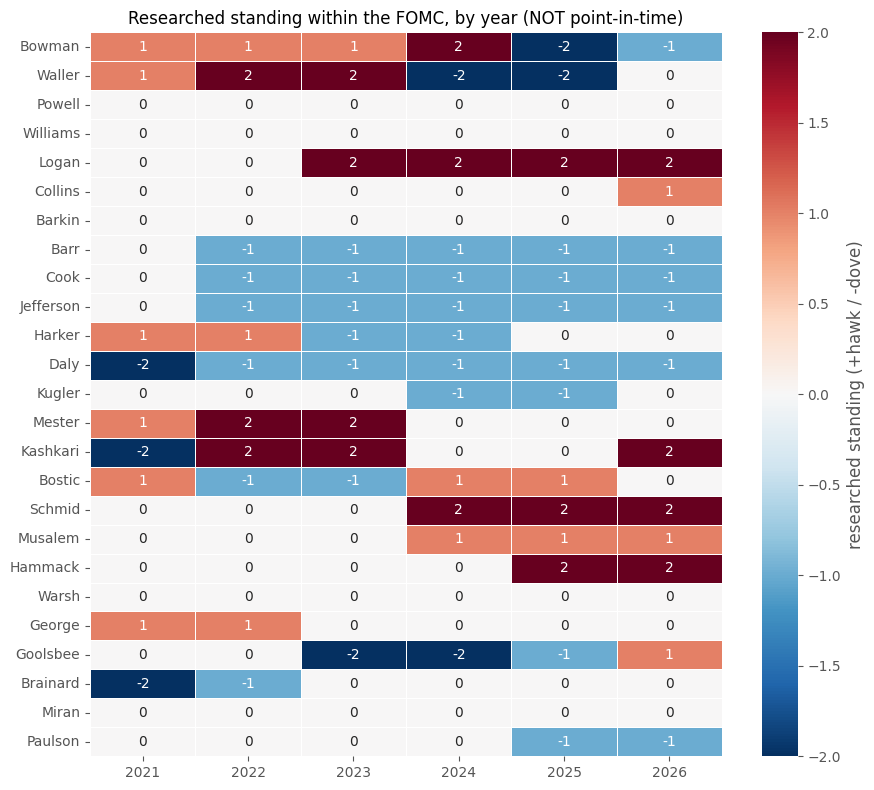

13 of 31 researched FOMC speakers changed side at least once:
  Powell      2021-01:+0  2026-05:+0
  Bowman      2021-01:+1  2024-01:+2  2025-06:-2  2026-01:-1
  Waller      2021-01:+1  2022-01:+2  2023-11:-2  2026-02:+0
  Collins     2022-07:+0  2025-12:+1
  Harker      2021-01:+1  2023-01:-1
  Kashkari    2021-01:-2  2022-01:+2  2024-01:+0  2026-01:+1  2026-04:+2
  Daly        2021-01:-2  2022-01:-1
  Bostic      2021-01:+1  2022-06:-1  2024-01:+1
  Hammack     2024-08:+0  2024-12:+2
  Mester      2021-01:+1  2022-01:+2
  Goolsbee    2023-01:-2  2025-01:-1  2025-12:+1
  Brainard    2021-01:-2  2022-01:-1


In [4]:
import json
stances = G.load_researched_stances(HERE / "research_stances.json")
fs = (stances.get(BANK) or {}).get("speakers", {})

years = list(range(2021, 2027))
present = [s for s in top.index if s in fs]
grid_rows = []
for sp in present:
    fn = G.make_researched_bucketer({BANK: {"speakers": {sp: fs[sp]}}}, BANK)
    grid_rows.append([fn(sp, np.nan, datetime.date(y, 7, 1)) for y in years])
mat = pd.DataFrame(grid_rows, index=present, columns=years)

fig, ax = plt.subplots(figsize=(9, max(4, .32 * len(mat))))
sns.heatmap(mat, cmap="RdBu_r", center=0, vmin=-2, vmax=2, annot=True, fmt="d",
            cbar_kws={"label": "researched standing (+hawk / -dove)"}, ax=ax,
            linewidths=.4, linecolor="white")
ax.set_title("Researched standing within the FOMC, by year (NOT point-in-time)")
plt.tight_layout(); plt.show()

movers = {k: v for k, v in fs.items() if len(v) > 1}
print(f"{len(movers)} of {len(fs)} researched FOMC speakers changed side at least once:")
for k, v in list(movers.items())[:12]:
    print(f"  {k:11s} " + "  ".join(f"{p['start']}:{p['stance']:+d}" for p in v))

## 2. Events, filters and the causal-bar gate

Speaker events come from ForexFactory where it carries a timestamp, and from the JPM reports
where it does not — those trade the whole session (we know the day, not the minute) and are tagged
`synthetic` so every result can be split by whether the timing was real or assumed.

The gate keeps an event only where a genuine bar exists at-or-before **both** entry and exit,
within the staleness bound, on a day that is not a padded grid. That converts pre-session
lookahead, stale marks and fake zeros into logged exclusions instead of silent P&L.

In [5]:
with open(CACHE / "events.pkl", "rb") as f:
    events_by_bank = pickle.load(f)
d = events_by_bank[BANK]
events = d["events"]
f_ = d.get("funnel", {})

row = {"forexfactory rows": f_.get("n_forexfactory_rows", 0),
       "timed events": f_.get("n_timed", 0),
       "synthetic events": f_.get("n_synthetic", 0)}
row.update({f"ff excluded: {k}": v for k, v in (f_.get("forexfactory") or {}).items()})
row.update({f"syn excluded: {k}": v for k, v in (f_.get("synthetic") or {}).items()})
row.update({f"gate: {k}": v for k, v in (d.get("gate_reasons") or {}).items()})
row["TRADEABLE"] = len(events)
row["  of which synthetic"] = sum(1 for e in events
                                  if e.get("timestamp_source") == "synthetic")
display(pd.Series(row).to_frame("FOMC"))

diag = d.get("diag")
if diag is not None and len(diag):
    ok = diag[diag.reason == "ok"]
    print("staleness of the marks actually traded (minutes since the last bar):")
    display(ok[["entry_stale_min", "exit_stale_min"]].describe().round(1).T)

,FOMC
forexfactory rows,1503
timed events,709
synthetic events,115
ff excluded: unknown_speaker,76
ff excluded: neutral_or_no_score,558
ff excluded: policy_blackout,8
ff excluded: not_business_day,46
ff excluded: window_too_short,106
syn excluded: neutral_or_no_score,255
syn excluded: already_timed,294


staleness of the marks actually traded (minutes since the last bar):


,count,mean,std,min,25%,50%,75%,max
entry_stale_min,475.0,0.2,0.9,0.0,0.0,0.0,0.0,13.0
exit_stale_min,475.0,0.3,0.7,0.0,0.0,0.0,0.0,7.0


## 3. Performance

473 closed trades  2023-05-05 12:15:00-04:00 -> 2026-08-06 09:00:00-04:00


,trades,total_bp,avg_bp,hit,sharpe,t_stat,max_dd
book,,,,,,,
equal weight (pnl_bp),473,103.5,0.2188,0.4567,0.6890,1.2427,-63.5
as sized (x |bucket|),473,226.5,0.4789,0.4567,0.9018,1.6264,-84.0


The engine sizes at |bucket| x BASE_BPV, but pnl_bp divides that back out, so the
equal-weight row is a DIFFERENT portfolio from the one actually held. Both are shown.


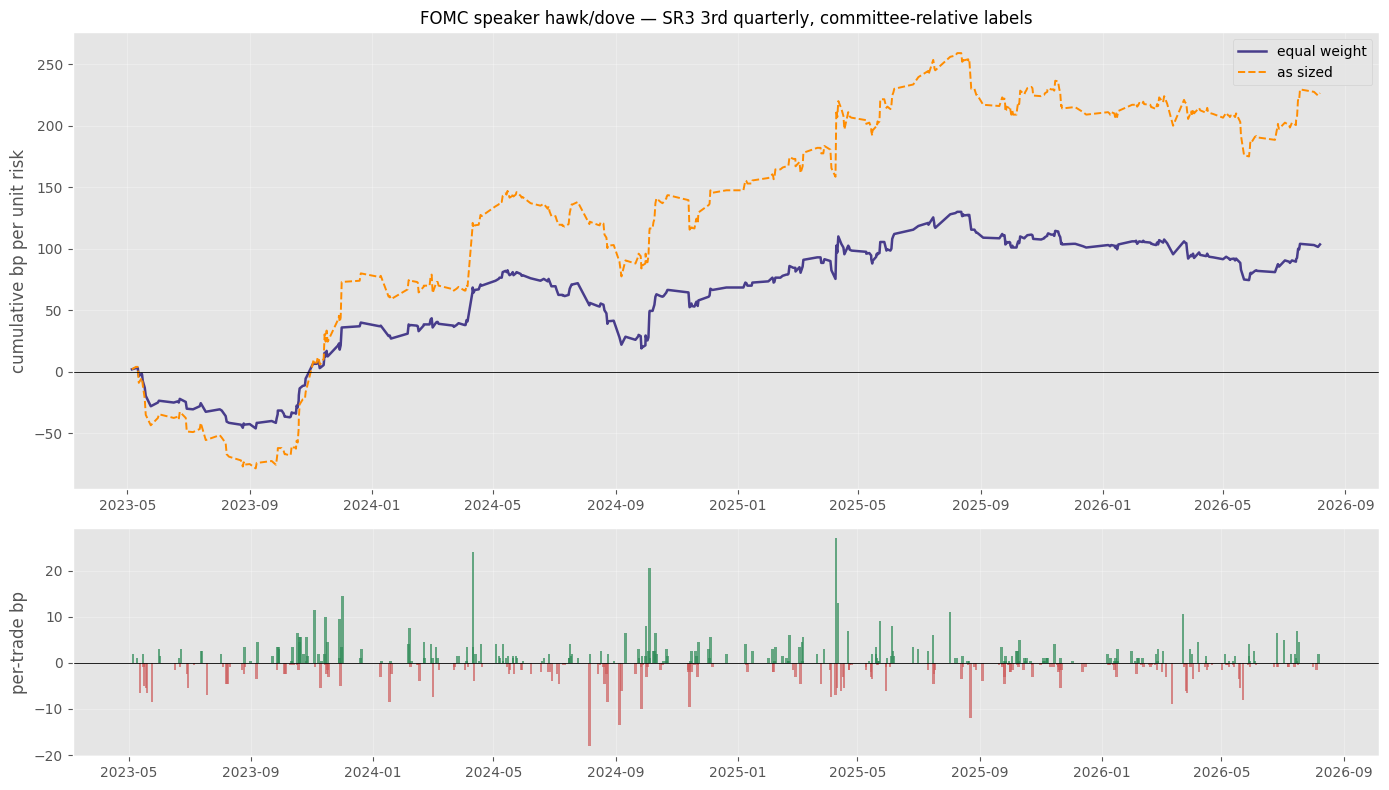

In [6]:
with open(CACHE / "closed.pkl", "rb") as f:
    closed_all = pickle.load(f)
closed = closed_all[BANK].sort_values("opened_at").reset_index(drop=True)
print(f"{len(closed)} closed trades  {closed.opened_at.min()} -> {closed.opened_at.max()}")

rows = []
for lbl, col in [("equal weight (pnl_bp)", "pnl_bp"),
                 ("as sized (x |bucket|)", "pnl_bp_sized")]:
    if col not in closed.columns:
        continue
    s = G.summarize(closed, pnl_col=col)
    rows.append({"book": lbl, "trades": s["trades"], "total_bp": s["total"],
                 "avg_bp": s["avg"], "hit": s["hit_rate"], "sharpe": s["sharpe"],
                 "t_stat": s["t_stat"], "max_dd": s["max_dd"]})
display(pd.DataFrame(rows).set_index("book").round(4))
print("The engine sizes at |bucket| x BASE_BPV, but pnl_bp divides that back out, so the")
print("equal-weight row is a DIFFERENT portfolio from the one actually held. Both are shown.")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [2, 1]})
ax = axes[0]
ax.plot(closed.opened_at.values, closed.pnl_bp.cumsum().values, lw=1.8,
        color="darkslateblue", label="equal weight")
if "pnl_bp_sized" in closed:
    ax.plot(closed.opened_at.values, closed.pnl_bp_sized.cumsum().values, lw=1.4,
            color="darkorange", ls="--", label="as sized")
ax.axhline(0, color="k", lw=.6); ax.legend(); ax.grid(alpha=.3)
ax.set_ylabel("cumulative bp per unit risk")
ax.set_title("FOMC speaker hawk/dove — SR3 3rd quarterly, committee-relative labels")

ax = axes[1]
c = ["seagreen" if x > 0 else "indianred" for x in closed.pnl_bp]
ax.bar(closed.opened_at.values, closed.pnl_bp.values, color=c, width=2.5, alpha=.7)
ax.axhline(0, color="k", lw=.6); ax.set_ylabel("per-trade bp"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 4. Who moves the market

This is the cut the pooled study cannot make. Two features of the FOMC are known at trade time
and cost nothing to condition on:

* **whether the speaker votes this year.** Governors always vote; regional presidents rotate on a
  published schedule fixed years in advance — New York every year, then
  (Boston, Philadelphia, Richmond), (Cleveland, Chicago), (Atlanta, St. Louis, Dallas),
  (Minneapolis, Kansas City, San Francisco).
* **their role** — Chair, Governor, or regional President.

Neither is fitted to the outcome, and both are the kind of thing a desk would condition on
anyway, which is what makes them worth more than a grid cell.

by voting status:


,trades,total_bp,avg_bp,hit,t_stat
is_voter,,,,,
does not vote,127,-74.5,-0.5866,0.3937,-2.0015
votes this year,346,178.0,0.5145,0.4798,2.4110


by role:


,trades,total_bp,avg_bp,hit,t_stat
role,,,,,
Chair,16,-10.5,-0.6563,0.3750,-0.6099
Governor,192,93.5,0.4870,0.4479,1.6164
President,238,3.5,0.0147,0.4664,0.0687
President (NY),27,17.0,0.6296,0.4815,0.6336


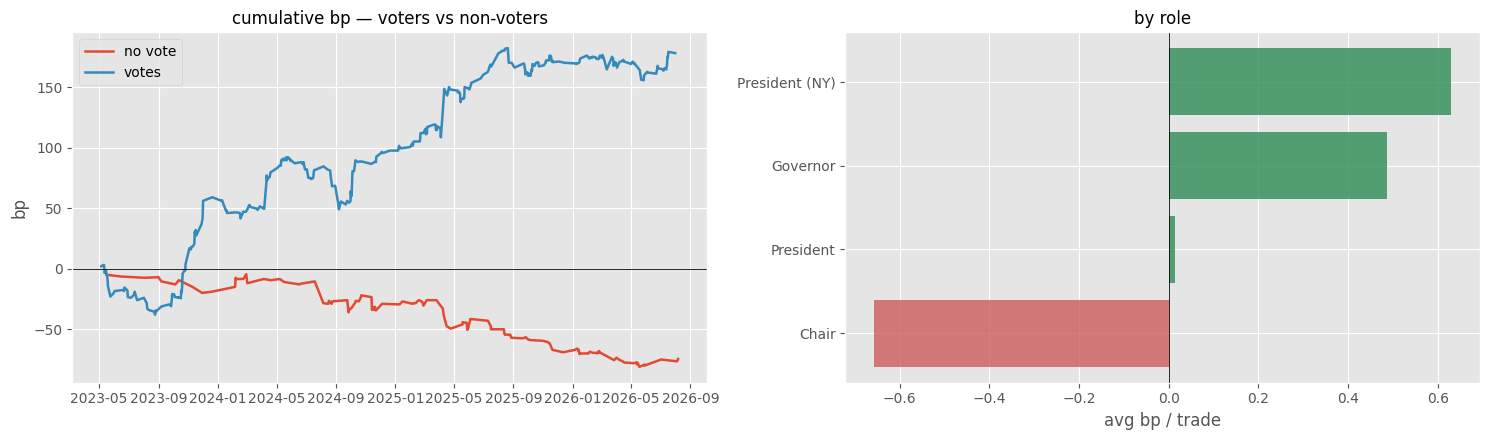

In [7]:
ann = FX.annotate(closed)

def block(g, by):
    t = g.groupby(by, observed=False).agg(
        trades=("pnl_bp", "size"), total_bp=("pnl_bp", "sum"),
        avg_bp=("pnl_bp", "mean"), hit=("profitable", "mean"))
    t["t_stat"] = g.groupby(by, observed=False)["pnl_bp"].apply(
        lambda x: x.mean() / (x.std(ddof=1) / np.sqrt(len(x))) if len(x) > 2 and x.std() else np.nan)
    return t.round(4)

print("by voting status:")
display(block(ann, ann["is_voter"].map({True: "votes this year", False: "does not vote"})
              .fillna("unknown")))
print("by role:")
display(block(ann, "role"))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
v = ann.dropna(subset=["is_voter"]).copy()
for lab, sub in v.groupby(v.is_voter.map({True: "votes", False: "no vote"})):
    sub = sub.sort_values("opened_at")
    axes[0].plot(sub.opened_at.values, sub.pnl_bp.cumsum().values, lw=1.8, label=lab)
axes[0].axhline(0, color="k", lw=.6); axes[0].legend()
axes[0].set_title("cumulative bp — voters vs non-voters"); axes[0].set_ylabel("bp")

r = ann.groupby("role")["pnl_bp"].mean().sort_values()
axes[1].barh(r.index, r.values,
             color=["indianred" if x < 0 else "seagreen" for x in r.values], alpha=.8)
axes[1].axvline(0, color="k", lw=.6); axes[1].set_xlabel("avg bp / trade")
axes[1].set_title("by role")
plt.tight_layout(); plt.show()

### 4.1 Is the voter split real, or just a cut that happened to work?

Two checks. A **permutation test** shuffles the voter flag across trades and asks how often a gap
this large appears by chance; a **split-half** check asks whether the gap is there in both halves
of the sample or only one. A cut that only survives in one half is a story about that half.

voter minus non-voter, avg bp/trade : +1.1011
two-sided permutation p-value       : 0.0056  (significant at 5%)


,voter avg,non-voter avg,gap,n voter,n non
half,,,,,
1st half,0.5738,-0.5377,1.1115,183,53
2nd half,0.4479,-0.6216,1.0695,163,74


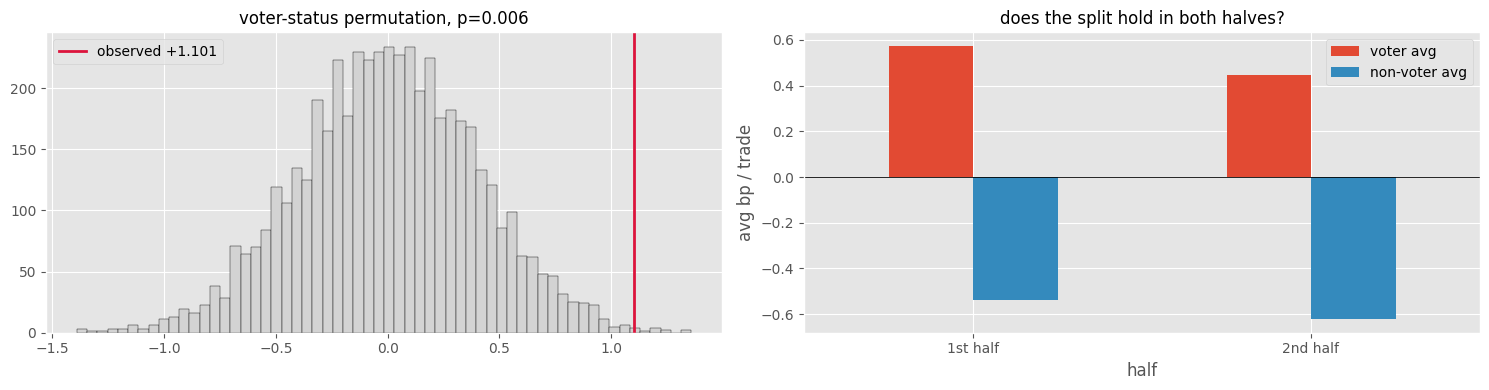

In [8]:
v = ann.dropna(subset=["is_voter"]).copy()
obs = v[v.is_voter].pnl_bp.mean() - v[~v.is_voter].pnl_bp.mean()

rng = np.random.default_rng(7)
flags = v.is_voter.to_numpy()
vals = v.pnl_bp.to_numpy()
perm = np.empty(5000)
for i in range(5000):
    f = rng.permutation(flags)
    perm[i] = vals[f].mean() - vals[~f].mean()
p = float((np.abs(perm) >= abs(obs)).mean())

print(f"voter minus non-voter, avg bp/trade : {obs:+.4f}")
print(f"two-sided permutation p-value       : {p:.4f}  ({'significant' if p < 0.05 else 'NOT significant'} at 5%)")

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].hist(perm, bins=60, color="lightgrey", edgecolor="k", lw=.3)
axes[0].axvline(obs, color="crimson", lw=2, label=f"observed {obs:+.3f}")
axes[0].set_title(f"voter-status permutation, p={p:.3f}"); axes[0].legend()

mid = len(v) // 2
rows = []
for name, sub in [("1st half", v.iloc[:mid]), ("2nd half", v.iloc[mid:])]:
    rows.append({"half": name,
                 "voter avg": sub[sub.is_voter].pnl_bp.mean(),
                 "non-voter avg": sub[~sub.is_voter].pnl_bp.mean(),
                 "gap": sub[sub.is_voter].pnl_bp.mean() - sub[~sub.is_voter].pnl_bp.mean(),
                 "n voter": int(sub.is_voter.sum()),
                 "n non": int((~sub.is_voter).sum())})
sh = pd.DataFrame(rows).set_index("half")
display(sh.round(4))
sh[["voter avg", "non-voter avg"]].plot(kind="bar", ax=axes[1], rot=0)
axes[1].axhline(0, color="k", lw=.6); axes[1].set_ylabel("avg bp / trade")
axes[1].set_title("does the split hold in both halves?")
plt.tight_layout(); plt.show()

### 4.1b Removing the governor confound — the closest thing here to a natural experiment

Governors vote at every meeting, so "voters" and "governors" overlap heavily and the split above
could just be saying *governors matter more than presidents*.

The clean test restricts to **regional presidents only**. Same population, same kind of speaker,
same job — differing only by whether the published rotation happens to give them a vote in that
calendar year. The rotation is fixed years in advance and has nothing to do with what they say or
what the market does, which is what makes this close to a natural experiment rather than a cut.

,trades,total_bp,avg_bp,hit
group,,,,
"regional president, VOTING this year",138,95.0,0.6884,0.5362
"regional president, NOT voting",127,-74.5,-0.5866,0.3937


gap +1.2750 bp/trade   two-sided permutation p = 0.0018


,voting avg,n voting,non-voting avg,n non,gap
year,,,,,
2023,1.2500,32,-1.9000,10,3.1500
2024,-0.0476,42,-0.2632,38,0.2155
2025,1.0930,43,-0.9091,44,2.0021
2026,0.4762,21,-0.1571,35,0.6333


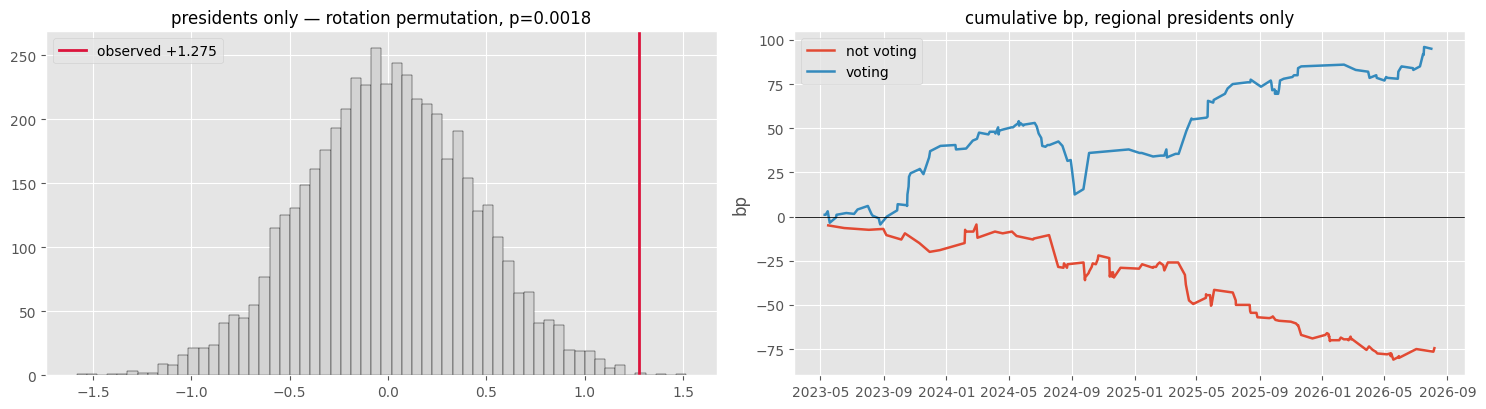


A voters-only book, after a 0.25bp round-trip cost:
  n=346  gross +178.0bp  net +91.5bp  (+0.5145 bp/trade gross)


In [9]:
pres = ann[ann.role.isin(["President", "President (NY)"])].dropna(subset=["is_voter"])
a = pres[pres.is_voter].pnl_bp
b = pres[~pres.is_voter].pnl_bp
obs_p = a.mean() - b.mean()

rng = np.random.default_rng(11)
f = pres.is_voter.to_numpy(); x = pres.pnl_bp.to_numpy()
perm_p = np.empty(5000)
for i in range(5000):
    ff = rng.permutation(f)
    perm_p[i] = x[ff].mean() - x[~ff].mean()
pval = float((np.abs(perm_p) >= abs(obs_p)).mean())

display(pd.DataFrame([
    {"group": "regional president, VOTING this year", "trades": len(a),
     "total_bp": a.sum(), "avg_bp": a.mean(), "hit": (a > 0).mean()},
    {"group": "regional president, NOT voting", "trades": len(b),
     "total_bp": b.sum(), "avg_bp": b.mean(), "hit": (b > 0).mean()},
]).set_index("group").round(4))
print(f"gap {obs_p:+.4f} bp/trade   two-sided permutation p = {pval:.4f}")

# does it hold year by year, and in both halves?
rows = []
pres = pres.copy(); pres["year"] = pd.to_datetime(pres.opened_at).dt.year
for y, sub in pres.groupby("year"):
    aa, bb = sub[sub.is_voter].pnl_bp, sub[~sub.is_voter].pnl_bp
    rows.append({"year": y, "voting avg": aa.mean(), "n voting": len(aa),
                 "non-voting avg": bb.mean(), "n non": len(bb),
                 "gap": aa.mean() - bb.mean()})
display(pd.DataFrame(rows).set_index("year").round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
axes[0].hist(perm_p, bins=60, color="lightgrey", edgecolor="k", lw=.3)
axes[0].axvline(obs_p, color="crimson", lw=2, label=f"observed {obs_p:+.3f}")
axes[0].set_title(f"presidents only — rotation permutation, p={pval:.4f}"); axes[0].legend()
for lab, sub in pres.groupby(pres.is_voter.map({True: "voting", False: "not voting"})):
    sub = sub.sort_values("opened_at")
    axes[1].plot(sub.opened_at.values, sub.pnl_bp.cumsum().values, lw=1.8, label=lab)
axes[1].axhline(0, color="k", lw=.6); axes[1].legend()
axes[1].set_title("cumulative bp, regional presidents only"); axes[1].set_ylabel("bp")
plt.tight_layout(); plt.show()

vb = ann.dropna(subset=["is_voter"])
vb = vb[vb.is_voter]
print(chr(10) + "A voters-only book, after a 0.25bp round-trip cost:")
print(f"  n={len(vb)}  gross {vb.pnl_bp.sum():+.1f}bp  net {vb.pnl_bp.sum() - .25*len(vb):+.1f}bp"
      f"  ({vb.pnl_bp.mean():+.4f} bp/trade gross)")

### 4.2 Speaker attribution

,trades,total_bp,avg_bp,hit,avg_score,role
speaker,,,,,,
Bowman,57,64.5,1.1316,0.4737,5.0000,Governor
Musalem,21,44.5,2.1190,0.7619,16.1905,President
Jefferson,16,22.0,1.3750,0.5625,-0.5000,Governor
Williams,27,17.0,0.6296,0.4815,9.7037,President (NY)
Goolsbee,43,8.5,0.1977,0.4884,4.1395,President
Miran,6,8.0,1.3333,0.3333,-11.8333,Governor
Schmid,11,7.5,0.6818,0.4545,23.7273,President
Kashkari,17,4.5,0.2647,0.5294,17.8235,President
Collins,14,3.5,0.2500,0.5000,10.2857,President


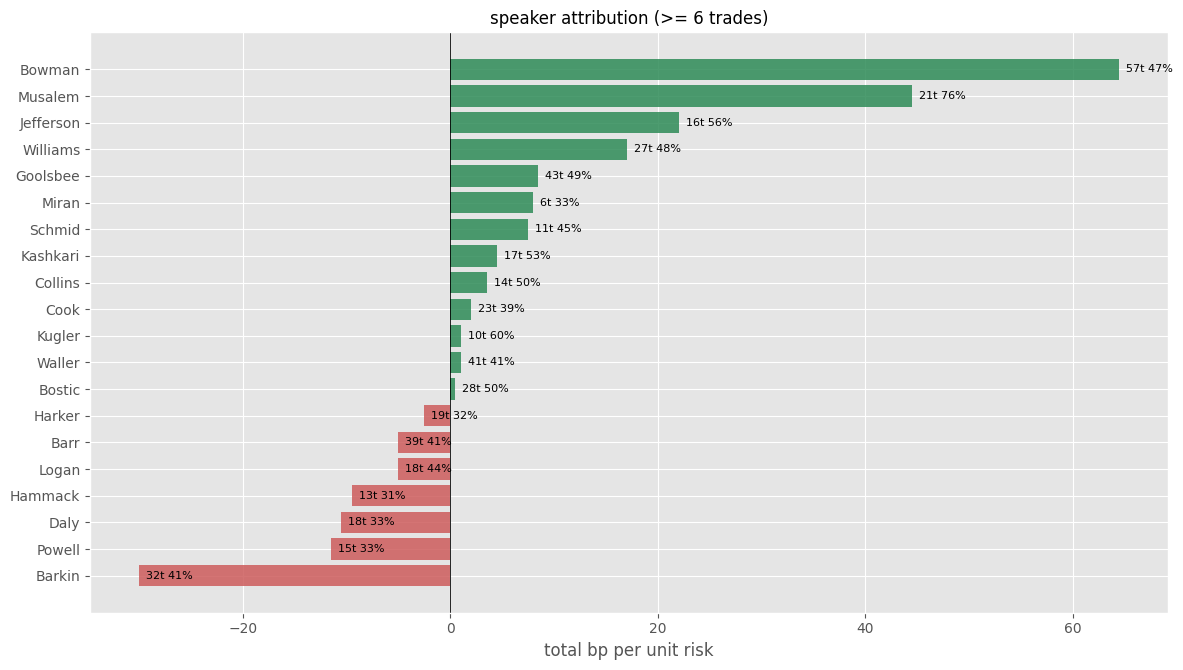

In [10]:
sp = (ann.groupby("speaker")
      .agg(trades=("pnl_bp", "size"), total_bp=("pnl_bp", "sum"),
           avg_bp=("pnl_bp", "mean"), hit=("profitable", "mean"),
           avg_score=("raw_score", "mean"))
      .sort_values("total_bp", ascending=False).round(4))
sp["role"] = [FX.role_of(s) for s in sp.index]
display(sp)

t = sp[sp.trades >= 6].sort_values("total_bp")
fig, ax = plt.subplots(figsize=(12, max(4, .34 * len(t))))
ax.barh(t.index, t.total_bp,
        color=["seagreen" if x > 0 else "indianred" for x in t.total_bp], alpha=.85)
ax.axvline(0, color="k", lw=.6); ax.set_xlabel("total bp per unit risk")
ax.set_title("speaker attribution (>= 6 trades)")
for i, (nm, r) in enumerate(t.iterrows()):
    ax.text(r.total_bp, i, f"  {int(r.trades)}t {r.hit:.0%}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

## 5. Where in the FOMC cycle

The meeting calendar is published years ahead, so distance-to-meeting is known at trade time.
Speeches inside the blackout are already excluded; what remains is whether a speech carries more
information early in the inter-meeting period, when the committee is genuinely re-forming its
view, than late, when the next decision is largely priced.

by phase of the inter-meeting cycle:


,trades,total_bp,avg_bp,hit,t_stat
cycle_phase,,,,,
0-14d after,190,12.5,0.0658,0.4474,0.2864
15-30d after,218,97.5,0.4472,0.4450,1.5015
30d+ / pre-meeting,65,-6.5,-0.1000,0.5231,-0.2269


by days to the NEXT decision:


,trades,total_bp,avg_bp,hit,t_stat
dtm_bucket,,,,,
<=7d,9,-6.5,-0.7222,0.4444,-0.5469
8-14d,70,42.0,0.6000,0.5714,1.2600
15-21d,97,55.0,0.5670,0.5052,1.5121
22-28d,92,-1.0,-0.0109,0.3370,-0.0232
29d+,205,14.0,0.0683,0.4488,0.2784


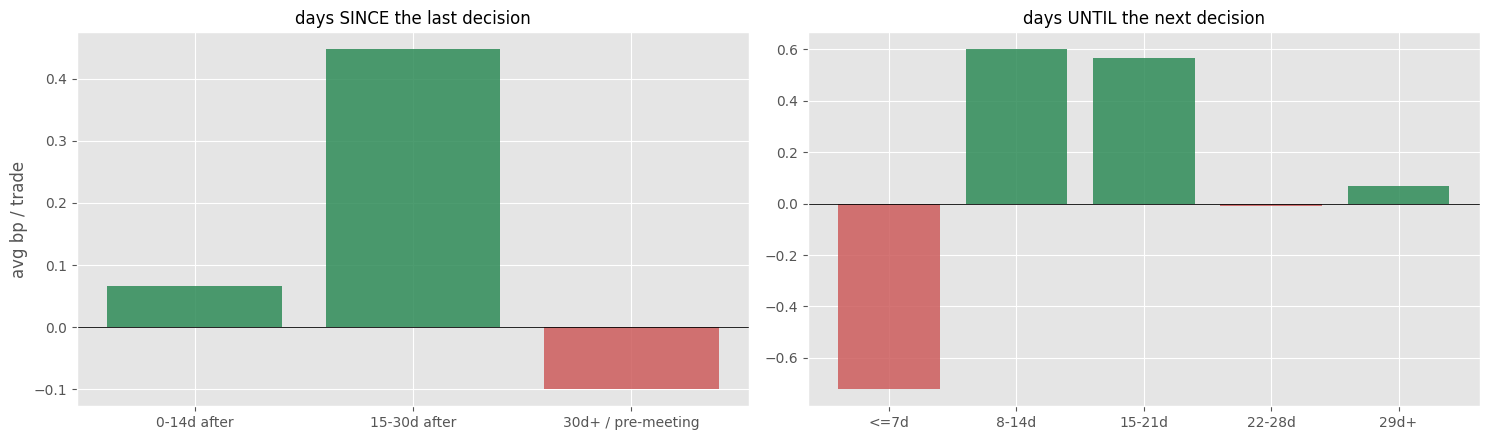

In [11]:
print("by phase of the inter-meeting cycle:")
display(block(ann, "cycle_phase"))

ann["dtm_bucket"] = pd.cut(ann.days_to_fomc, bins=[-1, 7, 14, 21, 28, 99],
                           labels=["<=7d", "8-14d", "15-21d", "22-28d", "29d+"])
print("by days to the NEXT decision:")
display(block(ann, "dtm_bucket"))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
c = ann.groupby("cycle_phase", observed=False)["pnl_bp"].mean()
axes[0].bar(c.index.astype(str), c.values,
            color=["seagreen" if x > 0 else "indianred" for x in c.values], alpha=.85)
axes[0].axhline(0, color="k", lw=.6); axes[0].set_ylabel("avg bp / trade")
axes[0].set_title("days SINCE the last decision")

b = ann.groupby("dtm_bucket", observed=False)["pnl_bp"].mean()
axes[1].bar(b.index.astype(str), b.values,
            color=["seagreen" if x > 0 else "indianred" for x in b.values], alpha=.85)
axes[1].axhline(0, color="k", lw=.6); axes[1].set_title("days UNTIL the next decision")
plt.tight_layout(); plt.show()

## 6. Does the signal scale with conviction?

The single most informative diagnostic in the whole study. A label that carries information should
earn **more** when it is more confident. If the strongest bucket is not the best bucket, the
"signal" is not ordered — which is very hard to reconcile with it being real.

by signed bucket:


,trades,total_bp,avg_bp,hit,t_stat
bucket,,,,,
-2,167,75.5,0.4521,0.4671,1.7385
-1,91,-9.0,-0.0989,0.4066,-0.2592
1,99,-10.5,-0.1061,0.4545,-0.2630
2,116,47.5,0.4095,0.4828,0.9983


by conviction |bucket|:


,trades,total_bp,avg_bp,hit,t_stat
abs_bucket,,,,,
1,190,-19.5,-0.1026,0.4316,-0.3695
2,283,123.0,0.4346,0.4735,1.9131


hawk vs dove:


,trades,total_bp,avg_bp,hit,t_stat
direction,,,,,
dove (long fut),258,66.5,0.2578,0.4457,1.1949
hawk (short fut),215,37.0,0.1721,0.4698,0.5960


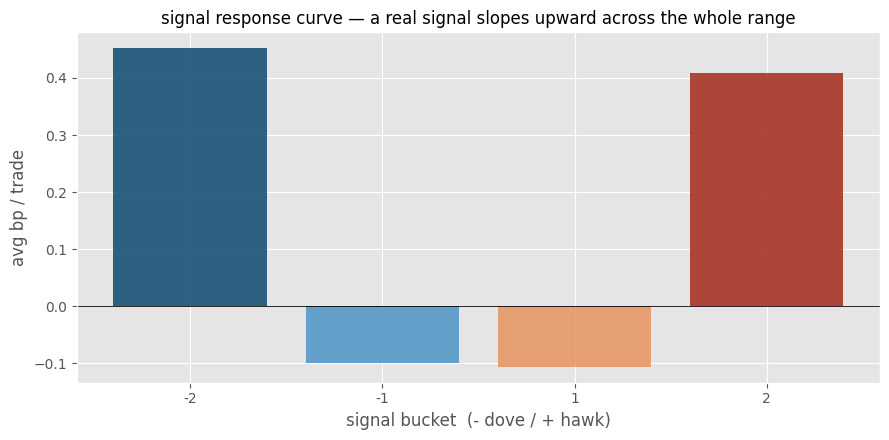

In [12]:
print("by signed bucket:")
display(block(ann, "bucket"))
print("by conviction |bucket|:")
display(block(ann, "abs_bucket"))
print("hawk vs dove:")
display(block(ann, "direction"))

b = ann.groupby("bucket")["pnl_bp"].mean()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(b.index.astype(str), b.values,
       color=["#1a5276", "#5499c7", "#e59866", "#a93226"][:len(b)], alpha=.9)
ax.axhline(0, color="k", lw=.6)
ax.set_xlabel("signal bucket  (- dove / + hawk)"); ax.set_ylabel("avg bp / trade")
ax.set_title("signal response curve — a real signal slopes upward across the whole range")
plt.tight_layout(); plt.show()

## 7. Calendar year, and the decay

,trades,total_bp,avg_bp,hit,t_stat
year,,,,,
2023,81,40.0,0.4938,0.4815,1.0982
2024,141,28.5,0.2021,0.5035,0.5484
2025,156,32.5,0.2083,0.4231,0.6897
2026,95,2.5,0.0263,0.4211,0.0931


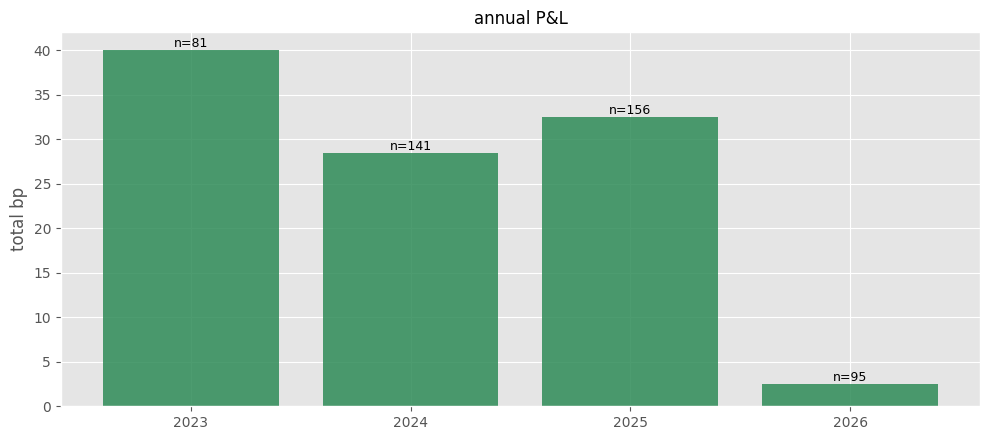

In [13]:
ann["year"] = pd.to_datetime(ann.opened_at).dt.year
yr = block(ann, "year")
display(yr)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(yr.index.astype(str), yr.total_bp,
       color=["seagreen" if x > 0 else "indianred" for x in yr.total_bp], alpha=.85)
ax.axhline(0, color="k", lw=.6); ax.set_ylabel("total bp")
for i, (y, r) in enumerate(yr.iterrows()):
    ax.text(i, r.total_bp, f"n={int(r.trades)}", ha="center",
            va="bottom" if r.total_bp >= 0 else "top", fontsize=9)
ax.set_title("annual P&L")
plt.tight_layout(); plt.show()

## 8. Robustness

sign-flip permutation — the null is that the LABEL carried no direction:
  realized Sharpe 0.690   null -0.002 +- 0.555   p=0.1078


,trades,total_bp,avg_bp,hit,sharpe,range
half,,,,,,
1st half,236,76.5,0.3242,0.4915,0.9013,2023-05-05 -> 2025-02-11
2nd half,237,27.0,0.1139,0.4219,0.4138,2025-02-11 -> 2026-08-06


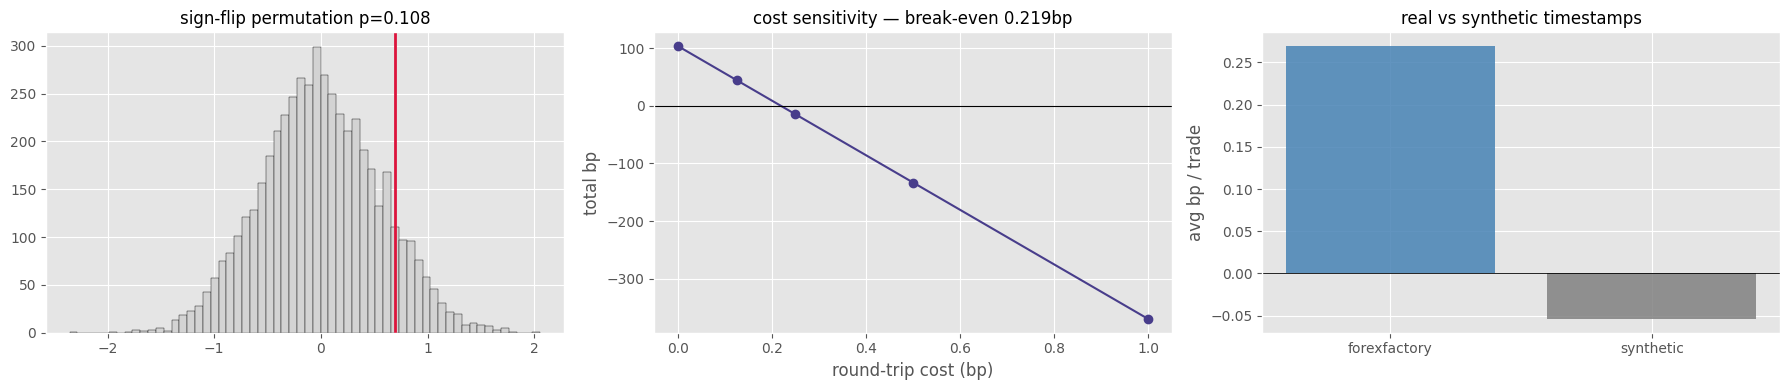

,size,sum,mean
timestamp_source,,,
forexfactory,399,107.5,0.2694
synthetic,74,-4.0,-0.0541


In [14]:
print("sign-flip permutation — the null is that the LABEL carried no direction:")
r = G.sign_flip_permutation(closed, n_perm=5000)
print(f"  realized Sharpe {r['realized_sharpe']:.3f}   null {r['perm_mean']:.3f}"
      f" +- {r['perm_std']:.3f}   p={r['p_value']:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(r["perm"], bins=60, color="lightgrey", edgecolor="k", lw=.3)
axes[0].axvline(r["realized_sharpe"], color="crimson", lw=2)
axes[0].set_title(f"sign-flip permutation p={r['p_value']:.3f}")

mid = len(closed) // 2
rows = []
for name, sub in [("1st half", closed.iloc[:mid]), ("2nd half", closed.iloc[mid:])]:
    s = G.summarize(sub)
    rows.append({"half": name, "trades": s["trades"], "total_bp": s["total"],
                 "avg_bp": s["avg"], "hit": s["hit_rate"], "sharpe": s["sharpe"],
                 "range": f"{s['first'].date()} -> {s['last'].date()}"})
display(pd.DataFrame(rows).set_index("half").round(4))

costs = [0.0, 0.125, 0.25, 0.5, 1.0]
tot = [closed.pnl_bp.sum() - c * len(closed) for c in costs]
axes[1].plot(costs, tot, marker="o", color="darkslateblue")
axes[1].axhline(0, color="k", lw=.8)
axes[1].set_xlabel("round-trip cost (bp)"); axes[1].set_ylabel("total bp")
axes[1].set_title(f"cost sensitivity — break-even {closed.pnl_bp.mean():.3f}bp")

prov = closed.groupby("timestamp_source")["pnl_bp"].agg(["size", "sum", "mean"])
axes[2].bar(prov.index, prov["mean"],
            color=["steelblue", "grey"][:len(prov)], alpha=.85)
axes[2].axhline(0, color="k", lw=.6); axes[2].set_ylabel("avg bp / trade")
axes[2].set_title("real vs synthetic timestamps")
plt.tight_layout(); plt.show()
display(prov.round(4))

### 8.1 Entry / exit window

Re-times every event, re-clamps it to the session and **re-gates** it, then re-prices. Re-gating
matters: a wider exit can walk past the last bar of the day, and an ungated re-run would mark it
against a lookahead bar instead of dropping it.

The baseline (−45, +180) is **inherited from the original Fed notebook, not chosen here** — but it
is also the argmax of this table, so treat the level with suspicion and read the *shape* instead.

bar cache: 9020 symbol-days


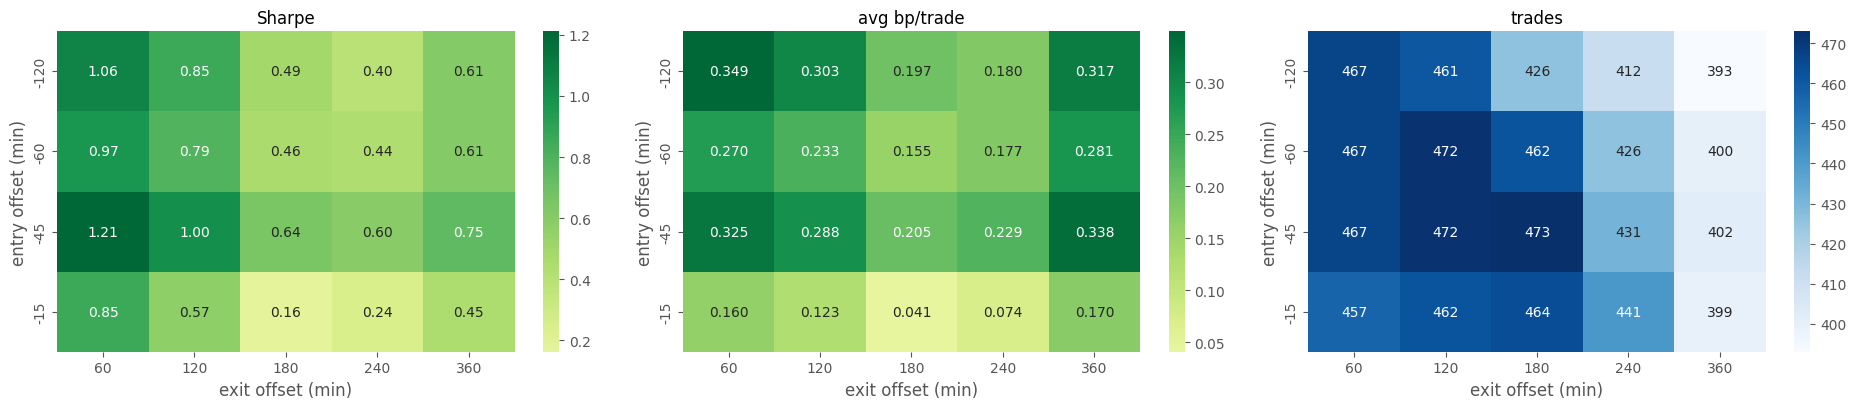

,variant,trades,total,avg,hit_rate,sharpe,t_stat
10,-45|60,467,152.0,0.3255,0.4497,1.2112,2.1844
0,-120|60,467,163.0,0.3490,0.4711,1.0601,1.9119
11,-45|120,472,136.0,0.2881,0.4640,1.0037,1.8101
5,-60|60,467,126.0,0.2698,0.4561,0.9673,1.7444
15,-15|60,457,73.0,0.1597,0.4245,0.8523,1.5372
1,-120|120,461,139.5,0.3026,0.4534,0.8514,1.5355
6,-60|120,472,110.0,0.2331,0.4703,0.7873,1.4199
14,-45|360,402,136.0,0.3383,0.4652,0.7455,1.3446


In [15]:
print(f"bar cache: {G.load_bar_cache(CACHE / 'bars.pkl')} symbol-days")
ENTRY_MIN = [-120, -60, -45, -15]
EXIT_MIN = [60, 120, 180, 240, 360]

variants = {f"{e}|{x}": (lambda bank, evs, _e=e, _x=x: G.rebuild_with_offsets(
    evs, cfg, datetime.timedelta(minutes=_e), datetime.timedelta(minutes=_x)))
    for e in ENTRY_MIN for x in EXIT_MIN}

sweep = G.sweep({BANK: events}, mdp, variants)
sweep[["entry", "exit"]] = sweep["variant"].str.split("|", expand=True).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(19, 4.2))
for ax, (val, fmt, ttl) in zip(axes, [("sharpe", ".2f", "Sharpe"),
                                      ("avg", ".3f", "avg bp/trade"),
                                      ("trades", ".0f", "trades")]):
    sns.heatmap(sweep.pivot(index="entry", columns="exit", values=val).astype(float),
                annot=True, fmt=fmt, cmap="RdYlGn" if val != "trades" else "Blues",
                center=0 if val != "trades" else None, ax=ax)
    ax.set_title(ttl); ax.set_xlabel("exit offset (min)"); ax.set_ylabel("entry offset (min)")
plt.tight_layout(); plt.show()
display(sweep.sort_values("sharpe", ascending=False).head(8)[
    ["variant", "trades", "total", "avg", "hit_rate", "sharpe", "t_stat"]].round(4))

## 9. The SOFR strip — a deflated instrument search

USD is the only leg where the strip stays liquid far enough out to search properly, so this goes
to the **8th quarterly contract** where the pooled study stopped at 6.

22+ structures — outrights, calendar spreads, butterflies and packs of four — times three causal
labelling schemes, times 16 entry/exit timings. Ranking that many configurations by Sharpe finds a
high Sharpe **whether or not any signal exists**, so the number that matters is the **Deflated
Sharpe Ratio**: given that we searched this hard, what is the probability the true Sharpe is above
zero? A configuration is interesting only at **DSR > 0.95**.

96 causal configs, selection hurdle SR* = 0.0947 per trade


,structure,kind,bucket_mode,trades,total_bp,avg_bp,hit,sharpe_ann,t_stat,dsr
0,OUT_1,outright,peer,467,70.2500,0.1504,0.3919,0.8791,1.5854,0.2982
1,OUT_1,outright,absolute,397,67.5000,0.1700,0.4055,0.8776,1.5828,0.3589
2,OUT_2,outright,peer,467,89.0000,0.1906,0.4368,0.7353,1.3260,0.2214
3,OUT_8,outright,peer,467,113.0000,0.2420,0.4839,0.7203,1.2990,0.2214
4,PACK_1,pack,peer,467,88.0625,0.1886,0.4904,0.7107,1.2817,0.2103
5,OUT_1,outright,percentile,462,57.7500,0.1250,0.3853,0.7006,1.2636,0.1957
6,OUT_2,outright,absolute,397,77.0000,0.1940,0.4635,0.6695,1.2074,0.2311
7,OUT_6,outright,peer,467,112.0000,0.2398,0.4732,0.6660,1.2012,0.1928
8,PACK_5,pack,peer,467,108.6250,0.2326,0.5054,0.6631,1.1958,0.1914
9,FLY_1_2_3,fly,absolute,397,6.2500,0.0157,0.4836,0.6605,1.1913,0.2406


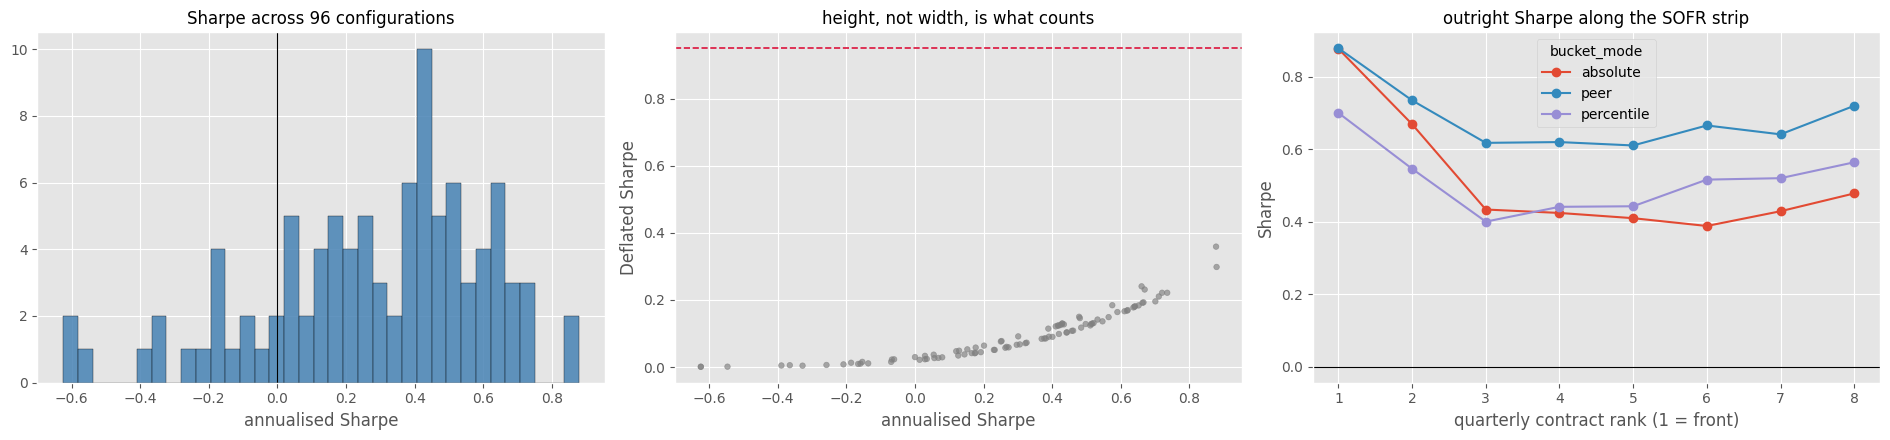

configs clearing DSR > 0.95 with >= 50 trades: 0 of 96


'NONE'


by structure family:


sharpe_ann                  avg_bp     dsr
              count  median     max  median     max
kind                                               
fly              18  0.0643  0.6605  0.0011  0.2406
outright         24  0.5554  0.8791  0.1801  0.3589
pack             15  0.5110  0.7107  0.1732  0.2103
spread           39  0.1526  0.4974  0.0063  0.1283

by labelling scheme:


sharpe_ann          avg_bp trades     dsr
                median     max  median median     max
bucket_mode                                          
absolute        0.2513  0.8776  0.0101  397.0  0.3589
peer            0.3532  0.8791  0.0131  467.0  0.2982
percentile      0.3888  0.7006  0.0130  462.0  0.1957

In [16]:
usd = pd.read_csv(CACHE / "usd_grid_results.csv")
show = ["structure", "kind", "bucket_mode", "trades", "total_bp", "avg_bp",
        "hit", "sharpe_ann", "t_stat", "dsr"]
print(f"{len(usd)} causal configs, selection hurdle SR* = {usd.sr_star.iloc[0]:.4f} per trade")
display(usd.sort_values("sharpe_ann", ascending=False)[show].head(20).round(4))

fig, axes = plt.subplots(1, 3, figsize=(19, 4.5))
axes[0].hist(usd.sharpe_ann, bins=35, color="steelblue", alpha=.85, edgecolor="k", lw=.3)
axes[0].axvline(0, color="k", lw=.8); axes[0].set_xlabel("annualised Sharpe")
axes[0].set_title(f"Sharpe across {len(usd)} configurations")

axes[1].scatter(usd.sharpe_ann, usd.dsr, s=16, alpha=.65,
                c=np.where(usd.dsr > .95, "seagreen", "grey"))
axes[1].axhline(.95, color="crimson", ls="--", lw=1.2)
axes[1].set_xlabel("annualised Sharpe"); axes[1].set_ylabel("Deflated Sharpe")
axes[1].set_title("height, not width, is what counts")

o = usd[usd.kind == "outright"].copy()
o["rank"] = o.structure.str.split("_").str[1].astype(int)
piv = o.pivot_table(index="rank", columns="bucket_mode", values="sharpe_ann")
piv.plot(marker="o", ax=axes[2])
axes[2].axhline(0, color="k", lw=.8)
axes[2].set_xlabel("quarterly contract rank (1 = front)"); axes[2].set_ylabel("Sharpe")
axes[2].set_title("outright Sharpe along the SOFR strip")
plt.tight_layout(); plt.show()

alive = usd[(usd.dsr > .95) & (usd.trades >= 50)]
print(f"configs clearing DSR > 0.95 with >= 50 trades: {len(alive)} of {len(usd)}")
display(alive[show].round(4) if len(alive) else "NONE")

print(chr(10) + "by structure family:")
display(usd.groupby("kind")[["sharpe_ann", "avg_bp", "dsr"]]
        .agg({"sharpe_ann": ["count", "median", "max"], "avg_bp": "median",
              "dsr": "max"}).round(4))
print("by labelling scheme:")
display(usd.groupby("bucket_mode")[["sharpe_ann", "avg_bp", "trades", "dsr"]]
        .agg({"sharpe_ann": ["median", "max"], "avg_bp": "median",
              "trades": "median", "dsr": "max"}).round(4))

### 9.1 What perfect knowledge of the committee would have been worth

The hand-researched standing table is not tradeable — it was written in 2026 about these very
trades. But scoring it answers a question worth knowing the answer to: **if you had known,
contemporaneously, exactly where each speaker sat on the committee, how much would that have been
worth?** That is the ceiling on the whole messenger-matters idea, and everything causal has to be
read against it.

`blended` takes the position only where the speech AND the speaker's standing agree — a known hawk
sounding hawkish, rather than any hawkish-sounding speech.

,tradeable,trades,total_bp,avg_bp,hit,sharpe,t_stat,hawk_share
scheme,,,,,,,,
peer,True,475,108.0,0.2274,0.4589,0.7200,1.2985,0.4568
percentile,True,470,76.5,0.1628,0.4511,0.4987,0.8994,0.4340
absolute,True,404,72.5,0.1795,0.4752,0.5081,0.9164,0.8045
researched,False,609,177.5,0.2915,0.4745,0.7540,1.7815,0.4893
blended,False,354,153.0,0.4322,0.4718,1.1744,2.1179,0.3757


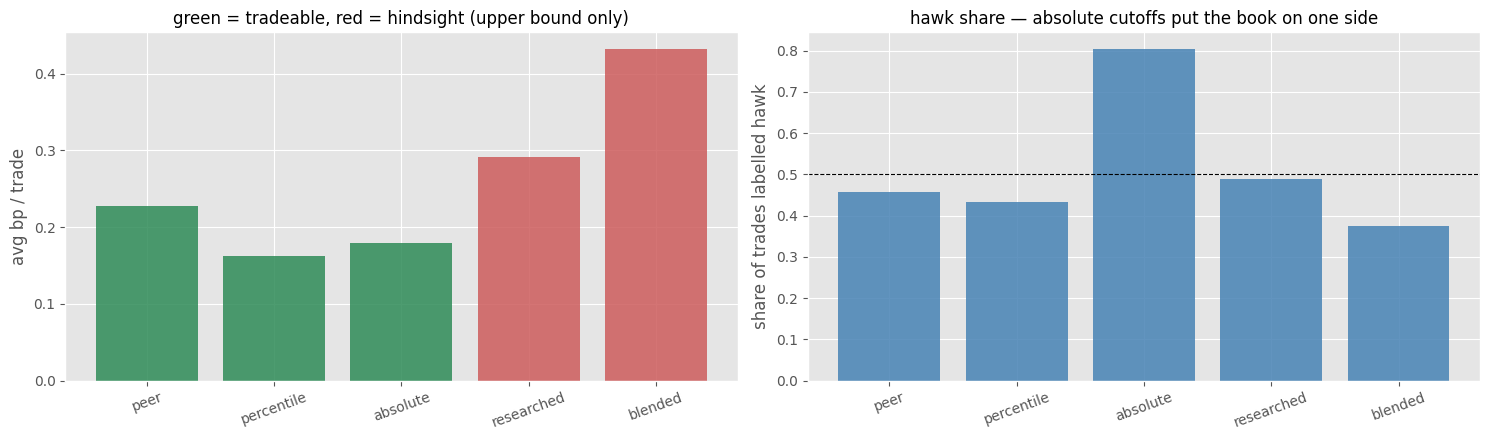

An adversarial audit measured an ORACLE version of this table at t=5.8 (one period per
speaker) and t=10.5 (speaker x year), while making its estimation window causal collapsed
it to t=0.9. Read the two red bars as a ceiling, not a strategy.


In [17]:
rows = []
for name, fname, causal in [("peer", "events.pkl", True),
                            ("percentile", "events_percentile.pkl", True),
                            ("absolute", "events_absolute.pkl", True),
                            ("researched", "events_researched.pkl", False),
                            ("blended", "events_blended.pkl", False)]:
    path = CACHE / fname
    if not path.exists():
        continue
    with open(path, "rb") as f:
        ev = pickle.load(f)
    evs = (ev.get(BANK) or {}).get("events") or []
    if not evs:
        continue
    fb = G.fast_backtest(evs)
    if fb.empty:
        continue
    s = G.summarize(fb)
    rows.append({"scheme": name, "tradeable": causal, "trades": s["trades"],
                 "total_bp": s["total"], "avg_bp": s["avg"], "hit": s["hit_rate"],
                 "sharpe": s["sharpe"], "t_stat": s["t_stat"],
                 "hawk_share": float((fb.bucket > 0).mean())})
lab = pd.DataFrame(rows).set_index("scheme")
display(lab.round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
c = ["seagreen" if t else "indianred" for t in lab.tradeable]
axes[0].bar(lab.index, lab.avg_bp, color=c, alpha=.85)
axes[0].axhline(0, color="k", lw=.6); axes[0].set_ylabel("avg bp / trade")
axes[0].set_title("green = tradeable, red = hindsight (upper bound only)")
axes[1].bar(lab.index, lab.hawk_share, color="steelblue", alpha=.85)
axes[1].axhline(.5, color="k", ls="--", lw=.8)
axes[1].set_ylabel("share of trades labelled hawk")
axes[1].set_title("hawk share — absolute cutoffs put the book on one side")
for ax in axes:
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

print("An adversarial audit measured an ORACLE version of this table at t=5.8 (one period per")
print("speaker) and t=10.5 (speaker x year), while making its estimation window causal collapsed")
print("it to t=0.9. Read the two red bars as a ceiling, not a strategy.")

## 10. Verdict

Read in this order.

1. **Did anything clear DSR > 0.95?** If not, the best Sharpe in the grid is what searching this
   many times produces from noise, and there is no instrument choice that rescues it.
2. **Does it clear costs?** Break-even is `avg_bp`; a listed SR3 outright is roughly a
   quarter-tick round trip.
3. **Is the response ordered in conviction?** If the strongest bucket is not the best bucket, the
   label is not measuring what it claims to.
4. **Is the voter split real?** This is the one conditioning variable here that is economically
   motivated rather than searched, so it is the finding most likely to survive contact with
   another sample.
5. **Does the edge persist?** Check the annual table and the second half.

In [18]:
real = closed[closed.timestamp_source == "forexfactory"]
v = ann.dropna(subset=["is_voter"])
summary = {
    "trades": int(len(closed)),
    "total_bp": round(float(closed.pnl_bp.sum()), 2),
    "avg_bp_per_trade": round(float(closed.pnl_bp.mean()), 4),
    "hit_rate": round(float(closed.profitable.mean()), 4),
    "sharpe": round(float(G.summarize(closed)["sharpe"]), 3),
    "t_stat": round(float(G.summarize(closed)["t_stat"]), 3),
    "sign_flip_p": round(float(r["p_value"]), 4),
    "break_even_rt_cost_bp": round(float(closed.pnl_bp.mean()), 4),
    "total_at_0.25bp_cost": round(float(closed.pnl_bp.sum() - .25 * len(closed)), 1),
    "real_timestamp_avg_bp": round(float(real.pnl_bp.mean()), 4),
    "voter_minus_nonvoter_bp": round(float(
        v[v.is_voter].pnl_bp.mean() - v[~v.is_voter].pnl_bp.mean()), 4),
    "grid_configs": int(len(usd)),
    "grid_best_sharpe": round(float(usd.sharpe_ann.max()), 3),
    "grid_best_dsr": round(float(usd.dsr.max()), 3),
    "grid_alive_dsr_gt_95": int(((usd.dsr > .95) & (usd.trades >= 50)).sum()),
}
for k, val in summary.items():
    print(f"  {k:26s} {val}")

pd.Series(summary).to_frame("value").to_csv(CACHE / "usd_fomc_summary.csv")
print(chr(10) + f"wrote {CACHE / 'usd_fomc_summary.csv'}")

  trades                     473
  total_bp                   103.5
  avg_bp_per_trade           0.2188
  hit_rate                   0.4567
  sharpe                     0.689
  t_stat                     1.243
  sign_flip_p                0.1078
  break_even_rt_cost_bp      0.2188
  total_at_0.25bp_cost       -14.7
  real_timestamp_avg_bp      0.2694
  voter_minus_nonvoter_bp    1.1011
  grid_configs               96
  grid_best_sharpe           0.879
  grid_best_dsr              0.359
  grid_alive_dsr_gt_95       0

wrote C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\_global_cache\usd_fomc_summary.csv


## 11. Trade log

In [19]:
log = ann[["opened_at", "closed_at", "speaker", "role", "district", "is_voter",
           "symbol", "direction", "bucket", "raw_score", "days_to_fomc",
           "timestamp_source", "pnl_bp"]].copy()
log["cum_bp"] = log.pnl_bp.cumsum()
display(log.style.format({"raw_score": "{:.1f}", "pnl_bp": "{:+.3f}",
                          "cum_bp": "{:+.2f}"})
        .bar(subset=["pnl_bp"], color=["#d65f5f", "#5fba7d"], align="zero"))
log.to_csv(CACHE / "usd_fomc_trade_log.csv", index=False)
print(f"wrote {CACHE / 'usd_fomc_trade_log.csv'}")

,opened_at,closed_at,speaker,role,district,is_voter,symbol,direction,bucket,raw_score,days_to_fomc,timestamp_source,pnl_bp,cum_bp
0,2023-05-05 12:15:00-04:00,2023-05-05 16:00:00-04:00,Cook,Governor,-,True,SR3Z23,dove (long fut),-1,17.0,40,forexfactory,+2.000,+2.00
1,2023-05-09 11:20:00-04:00,2023-05-09 15:05:00-04:00,Williams,President (NY),New York,True,SR3Z23,hawk (short fut),2,27.0,36,forexfactory,+1.000,+3.00
2,2023-05-11 08:15:00-04:00,2023-05-11 12:00:00-04:00,Kashkari,President,Minneapolis,True,SR3Z23,dove (long fut),-2,14.0,34,forexfactory,+0.000,+3.00
3,2023-05-12 09:00:00-04:00,2023-05-12 16:30:00-04:00,Bowman,Governor,-,True,SR3Z23,dove (long fut),-2,-1.0,33,synthetic,-6.500,-3.50
4,2023-05-15 07:45:00-04:00,2023-05-15 11:30:00-04:00,Goolsbee,President,Chicago,True,SR3Z23,dove (long fut),-2,10.0,30,forexfactory,+2.000,-1.50
5,2023-05-15 16:15:00-04:00,2023-05-15 16:45:00-04:00,Cook,Governor,-,True,SR3Z23,dove (long fut),-1,17.0,30,forexfactory,-1.000,-2.50
6,2023-05-16 09:00:00-04:00,2023-05-16 16:30:00-04:00,Mester,President,Cleveland,False,SR3Z23,dove (long fut),-1,19.0,29,synthetic,-5.000,-7.50
7,2023-05-18 08:20:00-04:00,2023-05-18 12:05:00-04:00,Jefferson,Governor,-,True,SR3Z23,dove (long fut),-2,3.0,27,forexfactory,-5.500,-13.00
8,2023-05-19 08:00:00-04:00,2023-05-19 11:45:00-04:00,Williams,President (NY),New York,True,SR3Z23,hawk (short fut),2,28.0,26,forexfactory,-6.500,-19.50
9,2023-05-24 09:00:00-04:00,2023-05-24 16:30:00-04:00,Waller,Governor,-,True,SR3Z23,dove (long fut),-1,17.0,21,synthetic,-8.500,-28.00


wrote C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\_global_cache\usd_fomc_trade_log.csv
